# Civic Trust 2026 — screening, quotas, weighting

**The study.** A national attitude survey on trust in institutions, fielded through an online panel: informed consent, screen-outs for minors and people living abroad, panel redirects, quotas by region and gender, weighting to census margins, and labelled tables, a banner, a report and SPSS/R files at the end.

**This directory** is the study as a small project — the notebook *imports* the modules instead of redefining them:

| File | Role |
| :--- | :--- |
| `codebook.py` | every `Variable`, defined once, registered in one `VariableMap` |
| `survey.py` | the `Questionnaire` + module-level `options` (compiler settings and the quota plan) |
| `helpers.py` | `flatten_responses()` (what the browser stores → one column per Variable) and `rake()` (weights) |
| `test_survey.py` | pytest smoke tests |
| `run_local.py` | local deploy → HTTP submissions → collect → quota monitor (script version of section 4) |
| `analysis.py` | cleaning, weights, tables, charts, report, exports (script version of sections 5–6) |

Every cell was executed against siamang 0.6.0; outputs are saved inline. Run the cells in order — the local server started in section 4 is stopped in section 7.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # make the study modules importable from any launcher

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
from siamang.core import validate_options

# Jupyter renders SurveyTable objects as HTML; make the text/plain fallback (text-only viewers,
# nbconvert --to script) show the Markdown table with its statistics footer instead of the dataclass repr.
for _cls in (FreqTable, CrossTable, GroupMeanTable):
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)
print("siamang", sg.__version__, "| working directory:", Path.cwd().name)

siamang 0.6.0 | working directory: civic_trust


## 1. The codebook: codebook.py

A declared missing code must also appear in `labels` (here `98: "Don't know"`), otherwise lint reports `MISSING_CODE_NOT_IN_LABELS`. Because the Matrix derives its columns from the shared labels, "Don't know" becomes a regular column whose code is declared missing.

In [2]:
print(Path("codebook.py").read_text())

"""Codebook for the Civic Trust 2026 study.

Every Variable is defined exactly once here and imported by the survey
module, the tests, and the analysis scripts, so the codebook can never
drift from the instrument.
"""

import siamang as sg
from siamang.core import MissingValue

# ── Shared label scales ──────────────────────────────────────────────────────
TRUST5 = {1: "No trust at all", 2: "Little trust", 3: "Some trust",
          4: "Quite a lot of trust", 5: "Complete trust"}
YESNO = {0: "No", 1: "Yes"}

# ── Screening ────────────────────────────────────────────────────────────────
consent = sg.Variable("consent", scale="nominal", label="Informed consent",
                      labels={1: "I agree to take part", 2: "I do not agree"})
age = sg.Variable("age", scale="ratio", label="Age (years)", dtype="int",
                  valid_range=(16, 99))
region = sg.Variable(
    "region", scale="nominal", label="Region of residence",
    labels={1: "Capital", 2: "North", 3: "South", 4: "E

## 2. The questionnaire and the quota plan: survey.py

- **Terminal pages are gated, and the same gate hides the main pages** — `simulate()` honours page gates but does not execute routing.
- **Page-level `show_if` must be SurveyJS-exportable.** `validate()` rejects `isin()` / `notin()` in a *page* gate (fine on blocks, questions, options and in `next_if`) — hence `working = OR(...)`.
- **`next_if` takes typed expressions** — `(Expression, page_name)` pairs, validated and compiled.
- **Quotas live in `options["quota"]`** (singular); `siamang validate` checks the plan, `survey.deploy(**options)` attaches it.

In [3]:
print(Path("survey.py").read_text())

"""Civic Trust 2026 — questionnaire module.

Run `siamang validate survey.py --strict`, `siamang preview survey.py`, or
import `survey` from Python. The module-level `options` dict carries the
compiler settings and the quota plan; `siamang validate` checks it too.
"""

import siamang as sg
from siamang.core import (
    AND, OR, ContentPage, DisqualificationPage, FinalPage, Quota,
)

from codebook import (
    ACTIVITIES, TRUST_ITEMS, age, comment, consent, education, employment, gender,
    interest, news_sources, recontact, region, variables, work_hours, work_sector,
)

PANEL = "https://panel.example.com/return"

# Respondents who consented and are adults see the main questionnaire.
eligible = AND(consent.eq(1), age.ge(18), region.ne(99))
# Page-level show_if must stay SurveyJS-exportable: no isin()/notin() there (see Part B2).
working = OR(employment.eq(1), employment.eq(2), employment.eq(3))

survey = sg.Questionnaire(
    title="Civic Trust 2026",
    variables=variables,
    page

In [4]:
from codebook import ACTIVITIES, TRUST_ITEMS, variables
from survey import eligible, options, survey

print(f"{len(survey.all_questions())} questions on {len(survey.pages)} pages; {len(variables)} variables; "
      f"{len(options['quota'])} quota cells")

14 questions on 10 pages; 21 variables; 6 quota cells


## 3. Validate like the CLI, test like a developer

The CLI imports the file by path, so the study directory must be on `PYTHONPATH` for `from codebook import ...` to resolve. `--strict` promotes measurement-model mistakes to errors; exit code 0 means clean.

In [5]:
!PYTHONPATH=. siamang validate survey.py --strict; echo "exit code: $?   (0 = valid)"

OK — no warnings.


exit code: 0   (0 = valid)


`test_survey.py` — validation, the quota plan, the eligibility gate and the simulator's missingness pattern:

In [6]:
print(Path("test_survey.py").read_text())

"""Smoke tests for the Civic Trust 2026 instrument — run with `pytest`."""

import pytest

from codebook import TRUST_ITEMS, variables
from survey import eligible, options, survey
from siamang.core import validate_options


def test_structure_is_valid():
    survey.validate(strict=True)              # raises on any structural problem
    validate_options(survey, options)         # quota cells match the codebook
    assert not [w for w in survey.lint(level="strict") if w.severity == "error"]


def test_eligibility_gate():
    assert eligible.evaluate({"consent": 1, "age": 34, "region": 2})
    assert not eligible.evaluate({"consent": 1, "age": 17, "region": 2})
    assert not eligible.evaluate({"consent": 2, "age": 40, "region": 1})
    assert not eligible.evaluate({"consent": 1, "age": 40, "region": 99})


def test_simulation_respects_gates():
    data = survey.simulate(n=300, seed=42)
    frame = data.frame
    assert frame.shape == (300, len(variables))
    ineligible = ~((frame["con

In [7]:
!PYTHONPATH=. python -m pytest -q test_survey.py

.....                                                                    [100%]


5 passed in 1.74s


In [8]:
survey.validate(strict=True); validate_options(survey, options)
print("strict lint:", [(w.severity, w.code) for w in survey.lint(level="strict")] or "clean")
print(eligible.to_surveyjs())
sim = survey.simulate(n=300, seed=42)
screened_out = ~((sim.frame["consent"] == 1) & (sim.frame["age"] >= 18) & (sim.frame["region"] != 99))
print(f"{int(screened_out.sum())} of 300 simulated respondents screened out (NaN on every gated page)")
sim.frame.head()

strict lint: clean
(({consent} = 1) and ({age} >= 18)) and ({region} != 99)
189 of 300 simulated respondents screened out (NaN on every gated page)


,consent,age,region,gender,education,employment,work_sector,work_hours,trust_govt,trust_parliament,...,trust_police,trust_media,interest,news_sources,act_vote,act_petition,act_protest,act_volunteer,comment,recontact
0,1,19,3,2.0,2.0,2.0,3.0,13.0,98.0,98.0,...,1.0,5.0,4.0,[1],0.0,1.0,0.0,0.0,sample text,1.0
1,1,87,2,99.0,2.0,4.0,NaN,NaN,5.0,3.0,...,2.0,98.0,4.0,"[3, 2]",1.0,0.0,1.0,0.0,sample text,1.0
2,2,28,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
3,2,93,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN
4,1,74,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN


## 4. The local deploy loop: what the browser actually stores

`survey.deploy()` with the defaults starts SQLite + a background FastAPI server (what `siamang preview` does). The React runtime posts its **whole answers store** (bookkeeping keys included), a `Matrix` as **one dict** under `matrix_<first var>`, and a wide `MultiChoice` as **a list of selected variable names** under `multi_<first var>`. `helpers.flatten_responses()` turns that payload into the per-Variable layout. (`run_local.py` is the script version of this section.)

In [9]:
print(Path("helpers.py").read_text())

"""Shared helpers for the Civic Trust study (imported by run_local.py, analysis.py and the notebook)."""

import numpy as np
import pandas as pd

import siamang as sg
from siamang.core import Matrix, MultiChoice
from siamang.core.question import question_output_name


def flatten_responses(frame: pd.DataFrame, survey: sg.Questionnaire) -> pd.DataFrame:
    """Turn collected runtime payloads into one column per Variable.

    The React runtime posts its whole answers store: bookkeeping keys
    (``__options__``, ``__pages__``, ``__errors__``), a ``{row: code}`` dict per
    Matrix, a list of selected variable names per wide MultiChoice and a
    ``{"selected": [...], "otherText": ...}`` dict for questions with other_specify.
    """
    frame = frame.loc[:, ~frame.columns.str.startswith("__")].copy()
    for q in survey.all_questions():
        qid = question_output_name(q)
        if isinstance(q, Matrix) and qid in frame.columns:
            cells = frame.pop(qid)
            for v in

In [10]:
from helpers import flatten_responses, rake

result = survey.deploy(backend_kwargs={"path": str(OUT / "survey.db")},
                       frontend_kwargs={"host": "127.0.0.1"}, **options)
print("survey_id:", result.survey_id, "| url:", result.url)

TEST_RESPONSES = [
    {"consent": 1, "age": 34, "region": 1, "gender": 2, "education": 4, "employment": 1,
     "work_sector": 2, "work_hours": 40,
     "matrix_trust_govt": {"trust_govt": 2, "trust_parliament": 3, "trust_courts": 4, "trust_police": 4, "trust_media": 98},
     "interest": 4, "news_sources": [3, 4], "multi_act_vote": ["act_vote", "act_petition"],
     "comment": "Interesting survey.", "recontact": 1, "__options__": {}, "__pages__": [], "__errors__": {}},
    {"consent": 1, "age": 61, "region": 3, "gender": 1, "education": 2, "employment": 5,
     "matrix_trust_govt": {"trust_govt": 3, "trust_parliament": 3, "trust_courts": 3, "trust_police": 5, "trust_media": 2},
     "interest": 2, "news_sources": [1], "multi_act_vote": ["act_vote"], "recontact": 2,
     "__options__": {}, "__pages__": [], "__errors__": {}},
    {"consent": 1, "age": 17, "region": 2, "__status": "screened_out", "__options__": {}, "__pages__": [], "__errors__": {}},
]
for answers in TEST_RESPONSES:
    r = requests.post(f"{result.url}/responses", json={"survey_id": result.survey_id, "responses": answers}, timeout=5)
    print(r.status_code, r.json())
raw = result.collect()
print("raw columns:", list(raw.columns))
raw

survey_id: ab2513feaa2f | url: http://127.0.0.1:47537
200 {'ok': True, 'response_id': 1}
200 {'ok': True, 'response_id': 2}
200 {'ok': True, 'response_id': 3}
raw columns: ['consent', 'age', 'region', 'gender', 'education', 'employment', 'work_sector', 'work_hours', 'matrix_trust_govt', 'interest', 'news_sources', 'multi_act_vote', 'comment', 'recontact', '__options__', '__pages__', '__errors__', '_response_id', '_submitted_at', '__status']


,consent,age,region,gender,education,employment,work_sector,work_hours,matrix_trust_govt,interest,news_sources,multi_act_vote,comment,recontact,__options__,__pages__,__errors__,_response_id,_submitted_at,__status
0,1,34,1,2.0,4.0,1.0,2.0,40.0,"{'trust_govt': 2, 'trust_parliament': 3, 'trus...",4.0,"[3, 4]","[act_vote, act_petition]",Interesting survey.,1.0,{},[],{},1,2026-09-03 01:50:19,NaN
1,1,61,3,1.0,2.0,5.0,NaN,NaN,"{'trust_govt': 3, 'trust_parliament': 3, 'trus...",2.0,[1],[act_vote],NaN,2.0,{},[],{},2,2026-09-03 01:50:19,NaN
2,1,17,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{},[],{},3,2026-09-03 01:50:19,screened_out


In [11]:
flat = flatten_responses(raw, survey).drop(columns=["_response_id", "_submitted_at"])
collected = sg.SurveyData(frame=flat, variables=variables, questionnaire=survey)
print("validation issues:", [(i.code, i.variable) for i in collected.validate()] or "none")
collected.frame[["age", "region", "trust_media", "act_vote", "act_petition", "news_sources"]]

validation issues: none


,age,region,trust_media,act_vote,act_petition,news_sources
0,34,1,98.0,1.0,1.0,"[3, 4]"
1,61,3,2.0,1.0,0.0,[1]
2,17,2,NaN,NaN,NaN,NaN


### Quota monitoring

In 0.6.0 the cells are validated, provisioned and countable, but the shipped runtime does not query them on its own — monitor the fill with the same predicate the backend uses and stop the survey when cells fill (Siamang Cloud tracks the cells live).

In [12]:
records = collected.frame.to_dict("records")
for cell in options["quota"]:
    n = sum(r.get(cell.variable) == cell.target_value for r in records)
    print(f"{cell.variable}={cell.target_value}: {n}/{cell.limit}{'  FULL' if cell.reached(records) else ''}")
print("backend counter:", result.backend_ref.check_quota(result.survey_id, "region", 1))
print("over HTTP:", requests.post(f"{result.url}/quota-check",
      json={"survey_id": result.survey_id, "variable": "region", "value": 1}, timeout=5).json())

region=1: 1/300
region=2: 1/250
region=3: 1/250
region=4: 0/200
gender=1: 1/520
gender=2: 1/520
backend counter: True
over HTTP: {'ok': True}


## 5. Analysis on rehearsal data

The steps of `analysis.py`, interactively. `apply_missing_values()` before alpha and index (otherwise "Don't know" = 98 is a very high trust score); `pd.to_numeric` after it (`replace()` leaves `object` columns); `recode()` bins are `[a, b)`; register the weight as `role="weight"`.

In [13]:
data = survey.simulate(n=1000, seed=42)
f = data.frame
data = data.with_frame(f[(f["consent"] == 1) & (f["age"] >= 18) & (f["region"] != 99)].reset_index(drop=True))
print(f"Analysis base: {len(data.frame)} | validation errors:", [i.code for i in data.validate() if i.severity == "error"] or "none")

clean = data.apply_missing_values()
trust_cols = [v.name for v in TRUST_ITEMS]
clean = clean.with_frame(clean.frame.assign(**{c: pd.to_numeric(clean.frame[c]) for c in trust_cols}))
print("Cronbach's alpha:", round(clean.scale_alpha(trust_cols), 3), "(≈ 0 or negative on uniform synthetic data — expected)")
clean = clean.create_index("trust_index", items=trust_cols, method="mean", label="Institutional trust index (1-5)")
clean = clean.recode("age", into="age_band", bins=[18, 30, 45, 65, 100],
                     labels=["18-29", "30-44", "45-64", "65+"], label="Age band")

CENSUS = {"region": {1: 0.31, 2: 0.24, 3: 0.27, 4: 0.18}, "age_band": {1: 0.19, 2: 0.26, 3: 0.33, 4: 0.22}}
weighted = clean.with_frame(clean.frame.assign(w=rake(clean.frame, CENSUS)))
weighted.variables.add(sg.Variable("w", scale="ratio", label="Raking weight", role="weight"))
weighted = weighted.with_weight("w")
print("Effective sample size (Kish):", round(weighted.analysis.effective_sample_size(), 1), "of", len(weighted.frame))
weighted.with_frame(weighted.frame.drop(columns=["news_sources"])).describe_variables().head(10)

Analysis base: 388 | validation errors: none
Cronbach's alpha: -0.024 (≈ 0 or negative on uniform synthetic data — expected)


Effective sample size (Kish): 301.0 of 388


,name,label,scale,n,n_missing,n_unique
0,consent,Informed consent,nominal,388,0,1
1,age,Age (years),ratio,388,0,81
2,region,Region of residence,nominal,388,0,4
3,gender,Gender,nominal,388,102,3
4,education,Highest education,ordinal,388,0,4
5,employment,Employment status,nominal,388,0,5
6,work_sector,Sector of employment,nominal,388,158,3
7,work_hours,Weekly working hours,ratio,388,158,79
8,trust_govt,Trust in the national government,ordinal,388,63,5
9,trust_parliament,Trust in parliament,ordinal,388,72,5


## 6. Tables, weighted statistics, charts, report

`data.report.*` tables are labelled but always unweighted; `data.analysis.*` and `data.tables.banner` honour the weight. `means()` picks ANOVA for the interval-scaled index and Kruskal–Wallis for the ordinal `interest`.

Reading the weighted `analysis.frequencies()` output: `n` is the **sum of weights** per code, `percent` is a **proportion** (multiply by 100), and the `NaN` row is the declared-missing "Don't know" answers that `apply_missing_values()` turned into NA — drop it with `dropna()` when you want the valid base.

In [14]:
weighted.report.freq('trust_govt')

Value,Label,N,%,Cumulative %
1.0,No trust at all,71,21.8,21.8
2.0,Little trust,70,21.5,43.3
3.0,Some trust,60,18.5,61.8
4.0,Quite a lot of trust,64,19.7,81.5
5.0,Complete trust,60,18.5,100.0
,Total,325,100.0,100.0


In [15]:
weighted.report.crosstab('region', 'trust_govt', pct='row')

Region of residence,No trust at all,Little trust,Some trust,Quite a lot of trust,Complete trust,Total
Capital,26.9,23.1,14.1,16.7,19.2,78
North,19.2,19.2,21.8,23.1,16.7,78
South,22.4,20.9,23.9,13.4,19.4,67
East,19.6,22.5,15.7,23.5,18.6,102
Total,71.0,70.0,60.0,64.0,60.0,325


In [16]:
weighted.report.means('trust_index', by='age_band')      # interval, 4 groups → ANOVA

Age band,Mean,SD,Median,N
18-29,2.999,0.761,3.0,53
30-44,3.157,0.703,3.2,81
45-64,3.006,0.735,3.0,84
65+,2.976,0.695,3.0,170


In [17]:
weighted.report.means('interest', by='region')           # ordinal, 4 groups → Kruskal-Wallis

Region of residence,Mean,SD,Median,N
Capital,2.882,1.301,3.0,93
North,2.711,1.421,3.0,97
South,3.047,1.345,3.0,86
East,3.223,1.406,3.0,112


In [18]:
wf = weighted.analysis.frequencies("trust_govt", labels=True, weighted=True)
display(wf)                                    # raw: NA row included, percent = proportion
display(wf.dropna(subset=["value"]).assign(percent=lambda t: (t["n"] / t["n"].sum() * 100).round(1)))  # valid base, %
tab, stats = weighted.analysis.crosstab("region", "trust_govt", normalize="index", chi2=True, cramers_v=True, weighted=True, labels=True)
print(stats)
print(weighted.analysis.proportion_ci("trust_govt", value=5, weighted=True))
weighted.analysis.grouped_mean("trust_index", by="region", weighted=True, labels=True)

,value,label,n,percent
0,1.0,No trust at all,65.882376,0.169800
1,2.0,Little trust,68.540076,0.176650
2,3.0,Some trust,64.619659,0.166546
3,4.0,Quite a lot of trust,59.935288,0.154472
4,5.0,Complete trust,64.009658,0.164973
5,NaN,NaN,65.012943,0.167559


,value,label,n,percent
0,1.0,No trust at all,65.882376,20.4
1,2.0,Little trust,68.540076,21.2
2,3.0,Some trust,64.619659,20.0
3,4.0,Quite a lot of trust,59.935288,18.6
4,5.0,Complete trust,64.009658,19.8


{'chi2': 14.885933206767486, 'p_value': 0.4596644960209363, 'dof': 15.0, 'cramers_v': 0.11308670307030917}
{'p': 0.16497334547829867, 'lower': 0.12304580196226617, 'upper': 0.20690088899433118, 'n': 301.03116923880714}


,group,mean,n,label
0,1,2.931223,120.28,Capital
1,2,3.081725,93.12,North
2,3,3.049822,104.76,South
3,4,3.072691,69.84,East


In [19]:
acts = [v.name for v in ACTIVITIES]
mentions = (weighted.frame[acts].mean() * 100).round(1).rename("percent").to_frame()
mentions.index = [variables[a].label for a in acts]
display(mentions)
long = weighted.frame[["news_sources"]].explode("news_sources").dropna()
base = weighted.frame["news_sources"].map(lambda s: isinstance(s, list) and len(s) > 0).sum()
news = long["news_sources"].value_counts().rename("n").to_frame().assign(percent=lambda t: (t["n"] / base * 100).round(1))
news.index = news.index.map(variables["news_sources"].labels)
news

,percent
Voted in an election,61.3
Signed a petition,66.8
Joined a demonstration,62.6
Volunteered,62.9


,n,percent
news_sources,,
I do not follow the news,146,37.6
Social media,93,24.0
Television,88,22.7
News websites,86,22.2
Radio,82,21.1
Newspapers,71,18.3


In [20]:
banner = weighted.tables.banner(rows=["trust_govt", "interest"], columns=["region", "age_band"])
banner.frame.head(8)

,row_variable,row_value,row_label,column_variable,column_value,column_label,n,percent
0,trust_govt,1.0,No trust at all,region,1,Capital,24.727639,0.240694
1,trust_govt,1.0,No trust at all,region,2,North,12.785612,0.165370
2,trust_govt,1.0,No trust at all,region,3,South,17.778970,0.222451
3,trust_govt,1.0,No trust at all,region,4,East,10.590156,0.168060
4,trust_govt,2.0,Little trust,region,1,Capital,24.182237,0.235385
5,trust_govt,2.0,Little trust,region,2,North,14.894911,0.192652
6,trust_govt,2.0,Little trust,region,3,South,15.526526,0.194269
7,trust_govt,2.0,Little trust,region,4,East,13.936402,0.221163


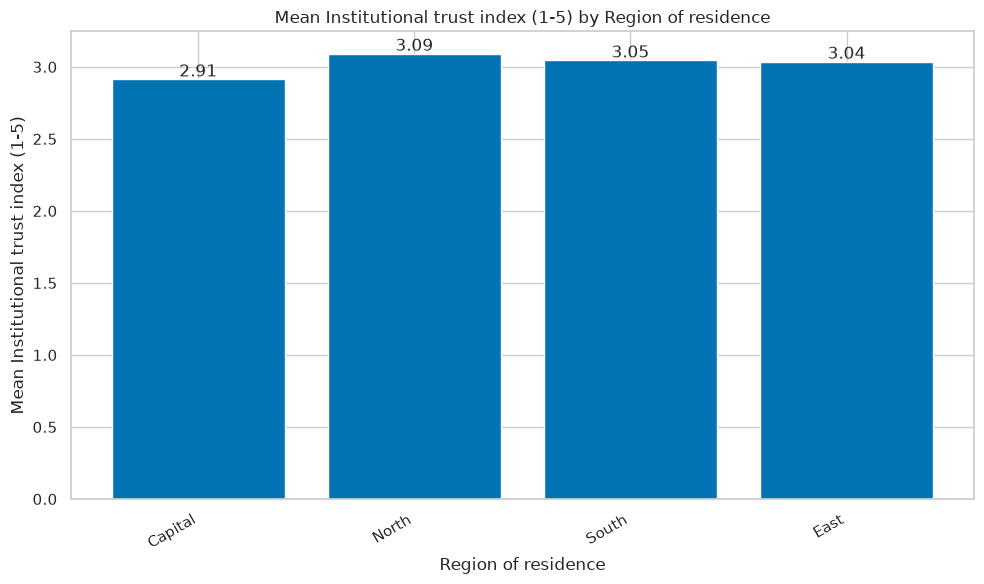

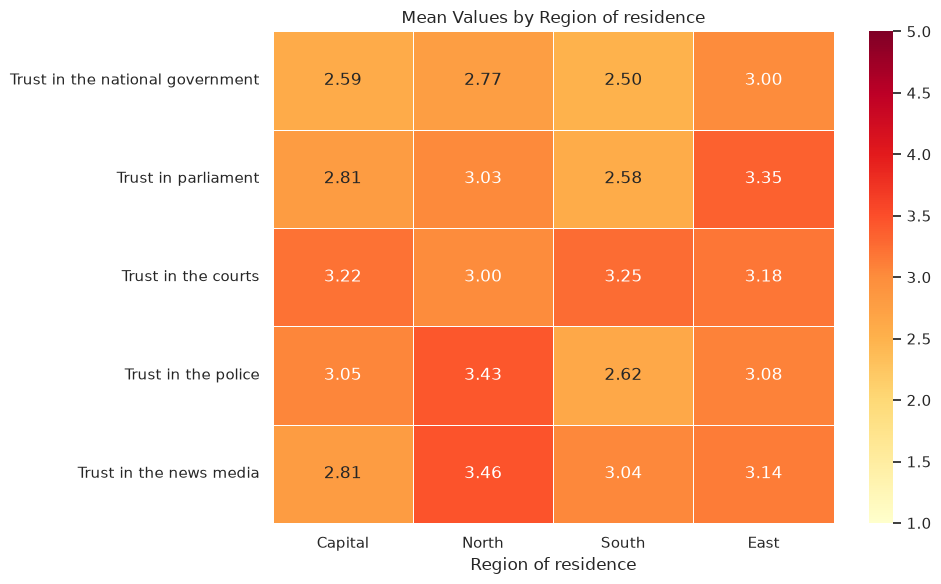

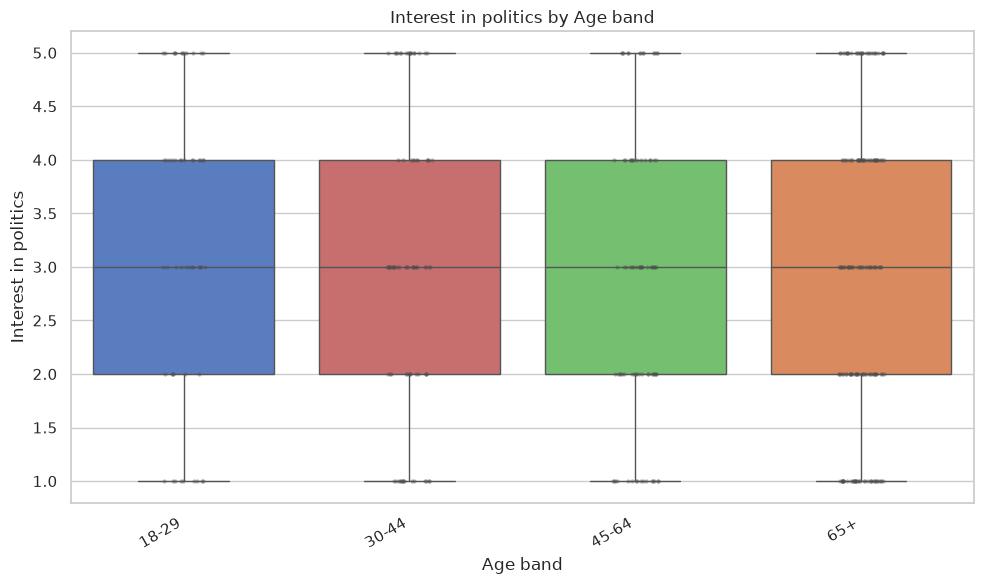

In [21]:
weighted.plot.bar("trust_index", by="region", palette="colorblind").plot(); plt.show()
weighted.plot.heatmap(trust_cols, by="region", vmin=1, vmax=5).plot(); plt.show()
weighted.plot.boxplot("interest", by="age_band", show_points=True).plot(); plt.show()

In [22]:
report = (sg.Report(title="Civic Trust 2026 — topline", description="Wave 1, weighted to census margins")
          .heading("Sample").value("Eligible respondents", len(weighted.frame))
          .value("Effective sample size", round(weighted.analysis.effective_sample_size()))
          .add(weighted.report.freq("region"), caption="Table 1. Region (unweighted)")
          .heading("Trust in institutions")
          .add(weighted.report.means("trust_index", by="age_band"), caption="Table 2. Trust index by age band")
          .add(weighted.plot.bar("trust_index", by="region", palette="colorblind"), caption="Figure 1. Mean trust index by region")
          .note("Estimates in the text are weighted; tables are unweighted counts."))
print(report.to_markdown(asset_dir=OUT)[:1000]); plt.close("all")

# Civic Trust 2026 — topline

*Wave 1, weighted to census margins*

## Sample

**Eligible respondents:** 388

**Effective sample size:** 301

*Table 1. Region (unweighted)*

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 1 | Capital | 93 | 24.0 | 24.0 |
| 2 | North | 97 | 25.0 | 49.0 |
| 3 | South | 86 | 22.2 | 71.2 |
| 4 | East | 112 | 28.9 | 100.1 |
|  | Total | 388 | 100.0 | 100.0 |

Variable = Region of residence; N valid = 388

## Trust in institutions

*Table 2. Trust index by age band*

| Age band | Mean | SD | Median | N |
|---|---|---|---|---|
| 18-29 | 2.999 | 0.761 | 3.0 | 53 |
| 30-44 | 3.157 | 0.703 | 3.2 | 81 |
| 45-64 | 3.006 | 0.735 | 3.0 | 84 |
| 65+ | 2.976 | 0.695 | 3.0 | 170 |

F = 1.2300; p = 0.2986; N = 388; Variable = Institutional trust index (1-5)

![Figure 1. Mean trust index by region](fig_6.png)

*Figure 1. Mean trust index by region*

> **Note:** Estimates in the text are weighted; tables are unweighted counts.



## 7. The script version and shutdown

`analysis.py` runs the same pipeline as a batch job and writes the banner, report (md + html), SPSS/Stata/CSV/dictionary and the R bundle to `out/`. With a CSV of flattened collected responses it takes the file as its argument.

In [23]:
!PYTHONPATH=. python analysis.py 2>&1 | tail -4

News websites              86     22.2
Radio                      82     21.1
Newspapers                 71     18.3
['banner.xlsx', 'civic_trust.csv', 'civic_trust.dta', 'civic_trust.sav', 'civic_trust_R', 'civic_trust_dict.json', 'fig_6.png', 'fig_7.png', 'survey.db', 'topline.html', 'topline.md']


In [24]:
result.frontend_ref.stop()
print("server stopped |", sorted(p.name for p in OUT.iterdir()))

server stopped | ['banner.xlsx', 'civic_trust.csv', 'civic_trust.dta', 'civic_trust.sav', 'civic_trust_R', 'civic_trust_dict.json', 'fig_6.png', 'fig_7.png', 'survey.db', 'topline.html', 'topline.md']
